<a href="https://colab.research.google.com/github/HKRM1006/S252/blob/main/notebook/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
!rm -rf S252
!git clone https://github.com/HKRM1006/S252.git
%cd S252

/content
Cloning into 'S252'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 122 (delta 57), reused 77 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 8.11 MiB | 24.35 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/S252


In [2]:
%pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:0

In [1]:
%cd S252

/content/S252


In [2]:
!python3 -m src.data.download_data

[*] Đang tải dataset từ Kaggle (PROPPG-PPG/hourly-weather-surface-brazil-southeast-region)...
100% 1.58G/1.58G [00:42<00:00, 39.6MB/s]
Extracting files...
[+] Đã tải và lưu tại: /content/S252/src/../data/raw/north.csv


In [3]:
from google.colab import userdata
import os

!python3 -m src.data.preprocessing --station A101 --keep 0.2

[load_station] Trạm A101: (36777, 24) (2017-02-18 15:00:00 → 2021-04-30 23:00:00)
[cleanse] Sau khi xử lý dữ liệu thiếu: (36776, 25)
[reduce] Sau reduction: (36776, 10)
[normalize] Đã scale 8 cột.

[preprocessing] Đã lưu 4 file vào '/content/S252/src/../data/processed'
  df_train : (29420, 9)  (2017-02-18 15:00:00 → 2020-06-28 10:00:00)
  df_test  : (7356, 9)   (2020-06-28 11:00:00  → 2021-04-30 22:00:00)


In [ ]:
!python3 -m run --mode baseline --extractor tsfel --output results_tsfel.csv


=== BASELINE – TSFEL ===
[baseline/tsfel] Đang extract features train...
Progress: |██████████████████████████████████████████████████| 100% Complete
[baseline/tsfel] Đang extract features test...
Progress: |██████████████████████████████████████████████████| 100% Complete
[Thông tin] TSFEL sinh ra tổng cộng: 405 features.
[LightGBM] [Info] Number of positive: 27083, number of negative: 27083
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.172889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 75917
[LightGBM] [Info] Number of data points in the train set: 54166, number of used features: 306
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Feature  Num Features  Computation Time (s) Model  Accuracy  Balanced Accuracy  Precision  Recall  F1-Score    MCC  ROC-AUC  PR-AUC  Time (s)
  TSFEL           405                613.28    RF    0.9242             0.7168     0.8236  

In [4]:
!python3 -m run --mode baseline --extractor tsfresh --output results_tsfresh.csv


=== BASELINE – TSFRESH ===

>>> [TRAIN] Bắt đầu xử lý...
2026-05-30 15:31:45 - WARNING - Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100% 60/60 [01:11<00:00,  1.20s/it]
   [Done] Batch 1: 500 ids saved to data/baseline/train/temp_batches/batch_0.parquet
2026-05-30 15:32:59 - WARNING - Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100% 60/60 [01:11<00:00,  1.19s/it]
   [Done] Batch 2: 500 ids saved to data/baseline/train/temp_batches/batch_500.parquet
2026-05-30 15:34:13 - WARNING - Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100% 60/60 [01:12<00:00,  1.20s/it]
   [Done] Batch 3: 500 ids saved to data/baseline/train/temp_batches/batch_1000.parquet
2026-05-30 15:35:28 - WARNING - Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100% 60/60 [01:11<00:00,  1.20s/it]
   [Done] Batch 4: 500 ids

In [ ]:
!python3 -m run --mode custom --output results_custom.csv


=== CUSTOM PIPELINE ====
2026-05-30 13:49:07 - INFO - Starting Lean Pipeline. Shape: (29419, 9)
2026-05-30 13:49:07 - INFO - Successfully appended 23 customized lag features.
2026-05-30 13:49:08 - INFO - Lean Pipeline finished successfully! Output shape: (29394, 231)
2026-05-30 13:49:08 - INFO - Starting Lean Pipeline. Shape: (7355, 9)
2026-05-30 13:49:08 - INFO - Successfully appended 23 customized lag features.
2026-05-30 13:49:08 - INFO - Lean Pipeline finished successfully! Output shape: (7330, 231)
100% 30/30 [00:05<00:00,  5.58it/s]

>>> TOP 30 FEATURES SELECTED BY mRMR:
  01. Precipitation
  02. Humidity_range_24h
  03. wet_streak_log
  04. Wind_Gust_diff_x_Wind_Speed_diff
  05. Precipitation_roll_3_mean
  06. Temperature_diff
  07. dry_streak_log
  08. wet_streak_hours
  09. Precipitation_diff_x_Temperature_diff
  10. Precipitation_zscore_24h
  11. Precipitation_lag_1
  12. wet_ratio_6h
  13. Temperature_diff_x_Wind_Gust_diff
  14. Humidity
  15. Precipitation_roll_3_std
  16.

#**Visualization**

In [3]:
from src.viz.data_parser import parse_csv_to_dataframe
import pandas as pd

df_tsfresh = parse_csv_to_dataframe("results_tsfresh.csv")
df_tsfel = parse_csv_to_dataframe("results_tsfel.csv")
df_custom = parse_csv_to_dataframe("results_custom.csv")

df_all = pd.concat([df_tsfresh, df_tsfel, df_custom], ignore_index=True)
cols = ['Feature'] + [col for col in df_all.columns if col != 'Feature']
df_final = df_all[cols]

print(df_final)

    Feature  Num Features  Computation Time (s) Model  Accuracy  \
0   TSFRESH          2030               5492.49    RF    0.9312   
1   TSFRESH          2030               5492.49    ET    0.9272   
2   TSFRESH          2030               5492.49   MLP    0.7967   
3   TSFRESH          2030               5492.49   KNN    0.7440   
4   TSFRESH          2030               5492.49    LR    0.7471   
5   TSFRESH          2030               5492.49   XGB    0.9300   
6   TSFRESH          2030               5492.49  LGBM    0.9349   
7     TSFEL           405                613.28    RF    0.9242   
8     TSFEL           405                613.28    ET    0.9235   
9     TSFEL           405                613.28   MLP    0.8682   
10    TSFEL           405                613.28   KNN    0.6836   
11    TSFEL           405                613.28    LR    0.8064   
12    TSFEL           405                613.28   XGB    0.9257   
13    TSFEL           405                613.28  LGBM    0.934

[Thành công] Đã lưu file ảnh: Precision -> 'viz/precision.png'


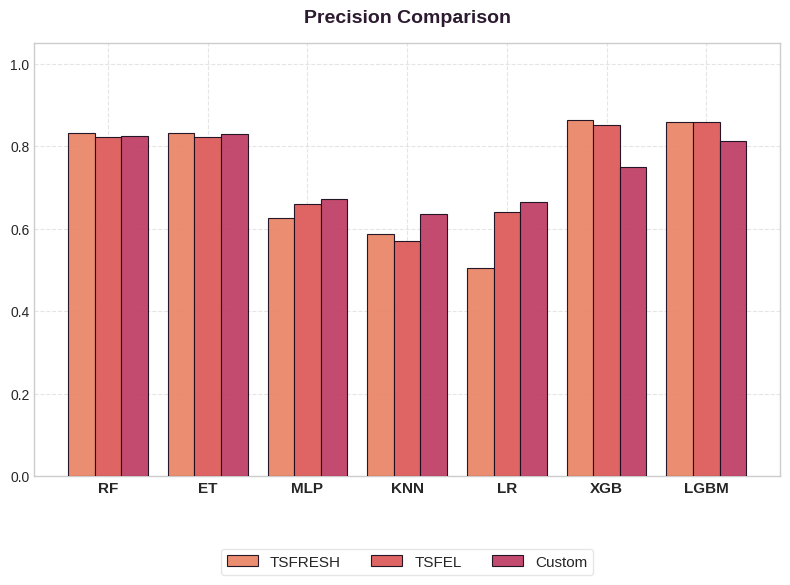

In [15]:
from src.viz.visualization_plot import *

plot_precision_metric(df_final,"viz/precision.png")


[Thành công] Đã lưu file ảnh: Recall -> 'viz/recall.png'


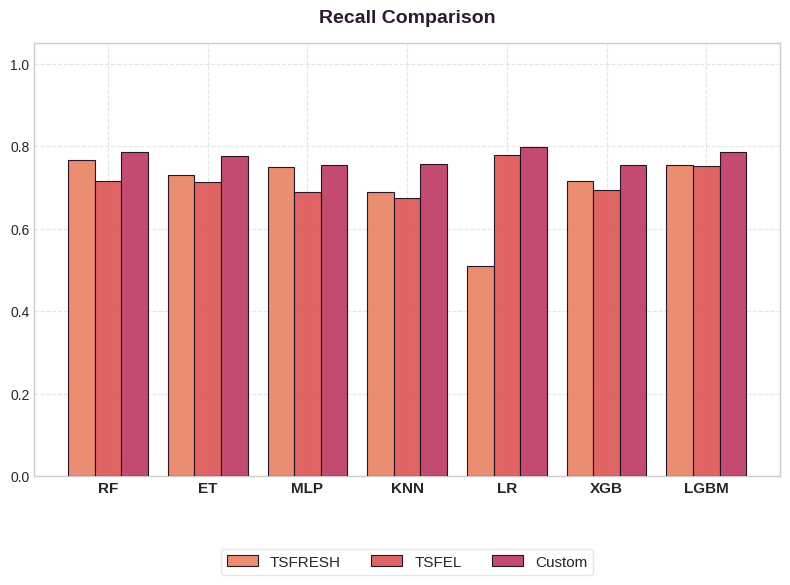

In [6]:
plot_recall_metric(df_final,"viz/recall.png")

[Thành công] Đã lưu file ảnh: F1-Score -> 'viz/f1.png'


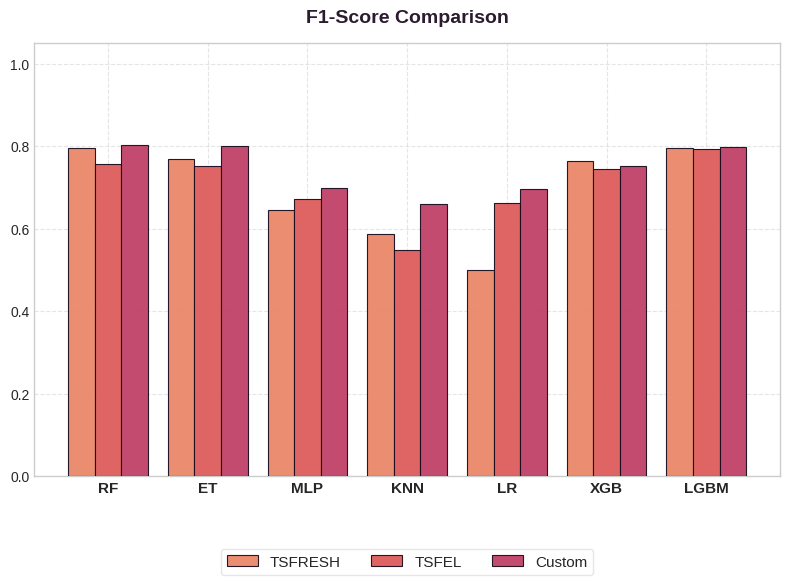

In [7]:
plot_f1_metric(df_final,"viz/f1.png")

[Thành công] Đã lưu file ảnh: Time -> 'viz/inference_time.png'


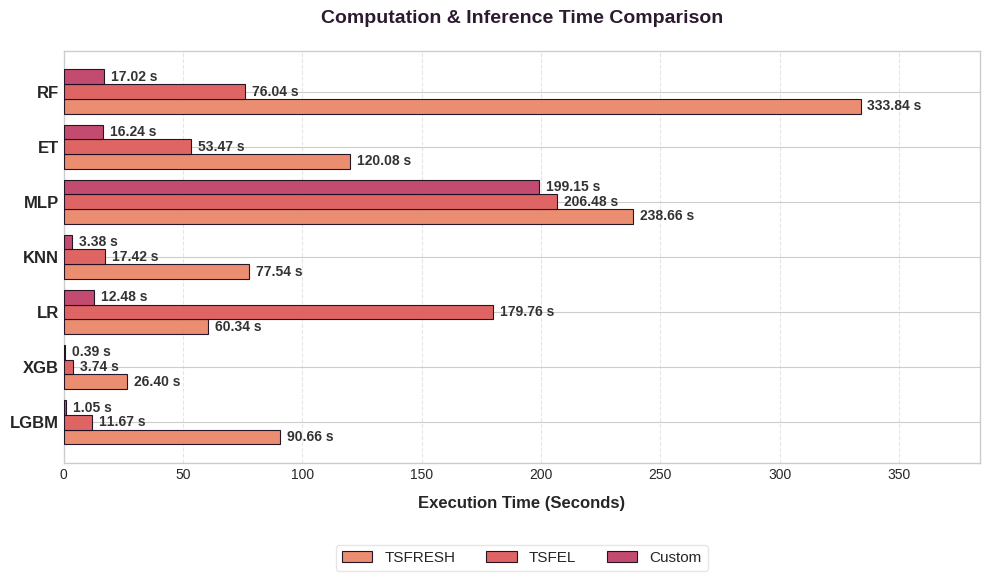

In [8]:
plot_inference_time(df_final,"viz/inference_time.png")

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FLARE_PALETTE = sns.color_palette("flare", 5)


def _setup_bar_positions(df, unique_models, unique_methods):
    """Hàm bổ trợ nội bộ: Tính toán độ rộng và vị trí các cột nhóm"""
    x = np.arange(len(unique_models))
    n_methods = len(unique_methods)
    width = 0.8 / n_methods if n_methods > 1 else 0.4
    return x, n_methods, width


def _ensure_dir_exists(file_path: str):
    """Hàm bổ trợ nội bộ: Tự động kiểm tra và tạo thư mục nếu chưa tồn tại"""
    dir_name = os.path.dirname(file_path)
    if dir_name and not os.path.exists(dir_name):
        os.makedirs(dir_name, exist_ok=True)
        print(f"[Hệ thống] Đã tự động khởi tạo thư mục: '{dir_name}/'")


def plot_precision_metric(df: pd.DataFrame, output_path: str):
    """Vẽ, lưu vào file và in ra console đồ thị chỉ số Precision"""
    _ensure_dir_exists(output_path)

    FEATURE_COL, MODEL_COL, METRIC = 'Feature', 'Model', 'Precision'
    unique_methods = df[FEATURE_COL].unique().tolist()
    unique_models = df[MODEL_COL].unique().tolist()

    x, n_methods, width = _setup_bar_positions(df, unique_models, unique_methods)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    for idx, m_name in enumerate(unique_methods):
        sub_df = df[df[FEATURE_COL] == m_name].set_index(MODEL_COL).reindex(unique_models).fillna(0)
        offset = (idx - (n_methods - 1) / 2) * width if n_methods > 1 else 0

        ax.bar(x + offset, sub_df[METRIC], width, label=m_name,
               color=FLARE_PALETTE[idx % len(FLARE_PALETTE)], edgecolor='#1a0d1f', linewidth=0.8, alpha=0.95, zorder=3)

    ax.set_title('Precision Comparison', fontsize=14, fontweight='bold', pad=15, color='#2c1a30')
    ax.set_xticks(x)
    ax.set_xticklabels(unique_models, fontsize=11, fontweight='bold')
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=n_methods,
              fontsize=11, frameon=True, facecolor='#ffffff', edgecolor='#e0e0e0')

    plt.tight_layout()


    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[Thành công] Đã lưu file ảnh: Precision -> '{output_path}'")


    plt.show()
    plt.close(fig)


def plot_recall_metric(df: pd.DataFrame, output_path: str):
    """Vẽ, lưu vào file và in ra console đồ thị chỉ số Recall"""
    _ensure_dir_exists(output_path)

    FEATURE_COL, MODEL_COL, METRIC = 'Feature', 'Model', 'Recall'
    unique_methods = df[FEATURE_COL].unique().tolist()
    unique_models = df[MODEL_COL].unique().tolist()

    x, n_methods, width = _setup_bar_positions(df, unique_models, unique_methods)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    for idx, m_name in enumerate(unique_methods):
        sub_df = df[df[FEATURE_COL] == m_name].set_index(MODEL_COL).reindex(unique_models).fillna(0)
        offset = (idx - (n_methods - 1) / 2) * width if n_methods > 1 else 0

        ax.bar(x + offset, sub_df[METRIC], width, label=m_name,
               color=FLARE_PALETTE[idx % len(FLARE_PALETTE)], edgecolor='#1a0d1f', linewidth=0.8, alpha=0.95, zorder=3)

    ax.set_title('Recall Comparison', fontsize=14, fontweight='bold', pad=15, color='#2c1a30')
    ax.set_xticks(x)
    ax.set_xticklabels(unique_models, fontsize=11, fontweight='bold')
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=n_methods,
              fontsize=11, frameon=True, facecolor='#ffffff', edgecolor='#e0e0e0')

    plt.tight_layout()


    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[Thành công] Đã lưu file ảnh: Recall -> '{output_path}'")
    plt.show()
    plt.close(fig)


def plot_f1_metric(df: pd.DataFrame, output_path: str):
    """Vẽ, lưu vào file và in ra console đồ thị chỉ số F1-Score"""
    _ensure_dir_exists(output_path)

    FEATURE_COL, MODEL_COL, METRIC = 'Feature', 'Model', 'F1-Score'
    unique_methods = df[FEATURE_COL].unique().tolist()
    unique_models = df[MODEL_COL].unique().tolist()

    x, n_methods, width = _setup_bar_positions(df, unique_models, unique_methods)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    for idx, m_name in enumerate(unique_methods):
        sub_df = df[df[FEATURE_COL] == m_name].set_index(MODEL_COL).reindex(unique_models).fillna(0)
        offset = (idx - (n_methods - 1) / 2) * width if n_methods > 1 else 0

        ax.bar(x + offset, sub_df[METRIC], width, label=m_name,
               color=FLARE_PALETTE[idx % len(FLARE_PALETTE)], edgecolor='#1a0d1f', linewidth=0.8, alpha=0.95, zorder=3)

    ax.set_title('F1-Score Comparison', fontsize=14, fontweight='bold', pad=15, color='#2c1a30')
    ax.set_xticks(x)
    ax.set_xticklabels(unique_models, fontsize=11, fontweight='bold')
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=n_methods,
              fontsize=11, frameon=True, facecolor='#ffffff', edgecolor='#e0e0e0')

    plt.tight_layout()


    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[Thành công] Đã lưu file ảnh: F1-Score -> '{output_path}'")
    plt.show()
    plt.close(fig)


def plot_inference_time(df: pd.DataFrame, output_path: str):
    """Vẽ, lưu vào file và in ra console đồ thị thời gian"""
    _ensure_dir_exists(output_path)

    FEATURE_COL, MODEL_COL, TIME_COL = 'Feature', 'Model', 'Time (s)'
    unique_methods = df[FEATURE_COL].unique().tolist()
    unique_models = df[MODEL_COL].unique().tolist()

    unique_models = unique_models[::-1]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    y = np.arange(len(unique_models))
    n_methods = len(unique_methods)
    height = 0.8 / n_methods if n_methods > 1 else 0.4

    for idx, m_name in enumerate(unique_methods):
        sub_df = df[df[FEATURE_COL] == m_name].set_index(MODEL_COL).reindex(unique_models).fillna(0)
        offset = (idx - (n_methods - 1) / 2) * height if n_methods > 1 else 0

        bars = ax.barh(y + offset, sub_df[TIME_COL], height, label=m_name,
                        color=FLARE_PALETTE[idx % len(FLARE_PALETTE)], edgecolor='#1a0d1f', linewidth=0.8, alpha=0.95, zorder=3)
        ax.bar_label(bars, fmt='%.2f s', padding=5, fontsize=10, fontweight='bold', color='#333333')

    ax.set_title('Inference Time Comparison', fontsize=14, fontweight='bold', pad=20, color='#2c1a30')
    ax.set_xlabel('Execution Time (Seconds)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_yticks(y)
    ax.set_yticklabels(unique_models, fontsize=12, fontweight='bold')
    ax.set_xlim(0, df[TIME_COL].max() * 1.15)
    ax.grid(True, linestyle='--', alpha=0.5, axis='x', zorder=0)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=n_methods,
              fontsize=11, frameon=True, facecolor='#ffffff', shadow=False, edgecolor='#e0e0e0')

    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[Thành công] Đã lưu file ảnh: Time -> '{output_path}'")
    plt.show()
    plt.close(fig)


def plot_extraction_time(df: pd.DataFrame, output_path: str):
    """
    Vẽ, lưu vào file và in ra console đồ thị so sánh thời gian trích xuất đặc trưng (Extraction/Computation Time).
    DataFrame đầu vào cần chứa ít nhất 2 cột: 'Feature' và 'Computation Time (s)'
    """
    _ensure_dir_exists(output_path)

    FEATURE_COL = 'Feature'
    TIME_COL = 'Computation Time (s)'

    df_copy = df.copy()
    df_copy[TIME_COL] = df_copy[TIME_COL].astype(float)

    unique_df = df_copy.groupby(FEATURE_COL)[TIME_COL].first().reset_index()

    unique_df = unique_df.iloc[::-1]

    methods = unique_df[FEATURE_COL].tolist()
    times = unique_df[TIME_COL].tolist()

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 4))

    y = np.arange(len(methods))
    height = 0.5

    bars = ax.barh(y, times, height,
                   color=[FLARE_PALETTE[i % len(FLARE_PALETTE)] for i in range(len(methods))],
                   edgecolor='#1a0d1f', linewidth=0.8, alpha=0.95, zorder=3)

    ax.bar_label(bars, fmt='%.2f s', padding=8, fontsize=11, fontweight='bold', color='#333333')


    ax.set_title('Feature Extraction Computation Time', fontsize=14, fontweight='bold', pad=20, color='#2c1a30')
    ax.set_xlabel('Execution Time (Seconds)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_yticks(y)
    ax.set_yticklabels(methods, fontsize=12, fontweight='bold')

    ax.set_xlim(0, max(times) * 1.20)
    ax.grid(True, linestyle='--', alpha=0.5, axis='x', zorder=0)

    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[Thành công] Đã lưu file ảnh thời gian trích xuất: '{output_path}'")
    plt.show()
    plt.close(fig)

[Thành công] Đã lưu file ảnh thời gian trích xuất: 'viz/extraction_time.png'


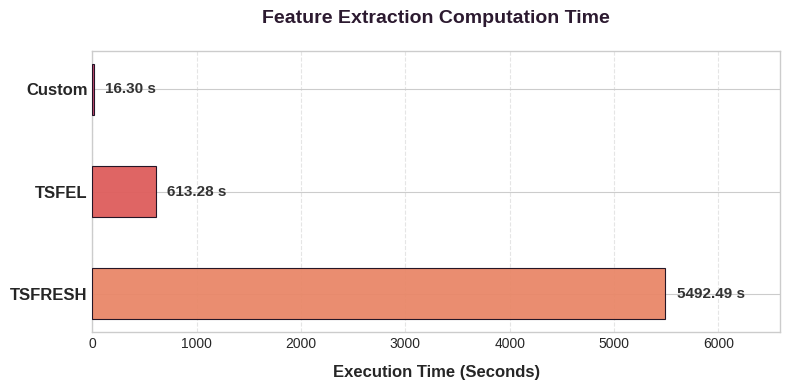

In [22]:
plot_extraction_time(df_final,"viz/extraction_time.png")